In [1]:
!python -V

Python 3.13.9


In [2]:
!pip list

Package                 Version
----------------------- -----------
appnope                 0.1.4
asttokens               3.0.2
catboost                1.2.10
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.21
decorator               5.3.1
executing               2.2.1
fonttools               4.63.0
graphviz                0.21
ipykernel               7.3.0
ipython                 9.15.0
ipython_pygments_lexers 1.1.1
jedi                    0.20.0
joblib                  1.5.3
jupyter_client          8.9.1
jupyter_core            5.9.1
kiwisolver              1.5.0
matplotlib              3.10.8
matplotlib-inline       0.2.2
narwhals                2.24.0
nest-asyncio2           1.7.2
numpy                   2.4.4
packaging               26.2
pandas                  3.0.2
parso                   0.8.7
pexpect                 4.9.0
pillow                  12.3.0
pip                     25.2
platformdirs            4.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import pickle
from pathlib import Path


In [4]:
np.random.seed(2026)

In [5]:
df = pd.read_csv('train_2.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 485082 entries, 0 to 485081
Data columns (total 24 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   new_id                                     485082 non-null  int64  
 1   Год                                        485082 non-null  int64  
 2   Месяц                                      485082 non-null  int64  
 3   Среднее количество промо товаров в чеке    485082 non-null  float64
 4   Среднее количество товаров в чеке          485082 non-null  float64
 5   Среднее количество отмен                   485082 non-null  float64
 6   Рабочие часы в день                        485082 non-null  float64
 7   Дата открытия, категориальный              485082 non-null  str    
 8   Торговая площадь, категориальный           485082 non-null  str    
 9   Населенный пункт                           485082 non-null  str    
 10  Регион             

In [6]:
missing_percent = df.isnull().sum() / len(df) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
print(missing_percent)

full_duplicates = df.duplicated().sum()
print(f"Дубликатов строк: {full_duplicates}")

key_duplicates = df.duplicated(subset=['new_id', 'Год', 'Месяц']).sum()
print(f"Дубликатов по ключу (id+год+месяц): {key_duplicates}")

Series([], dtype: float64)
Дубликатов строк: 0
Дубликатов по ключу (id+год+месяц): 0


In [7]:
df['date'] = pd.to_datetime(df[['Год', 'Месяц']].assign(day=1).rename(
    columns={'Год': 'year', 'Месяц': 'month'}
))

df = df.sort_values(['new_id', 'date']).reset_index(drop=True)

print(f"Диапазон дат: {df['date'].min()} — {df['date'].max()}")
print(f"Уникальных периодов: {df['date'].nunique()}")
print(f"Уникальных магазинов: {df['new_id'].nunique()}")

Диапазон дат: 2023-01-01 00:00:00 — 2025-02-01 00:00:00
Уникальных периодов: 26
Уникальных магазинов: 18657


In [8]:
total_months = df["date"].nunique()
store_counts = df.groupby("new_id")["date"].count()

print(f"Магазинов с полной историей: {(store_counts == total_months).sum()}")
print(f"Магазинов с неполной историей: {(store_counts < total_months).sum()}")

Магазинов с полной историей: 18657
Магазинов с неполной историей: 0


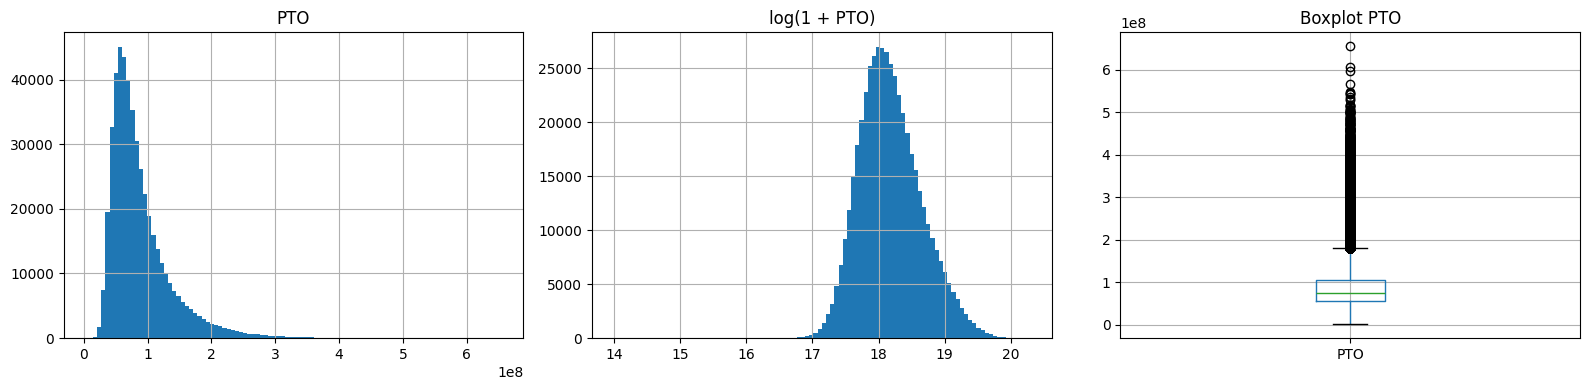

Асимметрия РТО: 1.986
Нулевых значений: 0


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df["РТО"].hist(bins=100, ax=axes[0])
axes[0].set_title("РТО")

np.log1p(df["РТО"]).hist(bins=100, ax=axes[1])
axes[1].set_title("log(1 + РТО)")

df.boxplot(column="РТО", ax=axes[2])
axes[2].set_title("Boxplot РТО")

plt.tight_layout()
plt.savefig("images/target_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Асимметрия РТО: {df['РТО'].skew():.3f}")
print(f"Нулевых значений: {(df['РТО'] == 0).sum()}")

In [10]:
q1 = df.groupby('new_id')['РТО'].transform(lambda x: x.quantile(0.25))
q3 = df.groupby('new_id')['РТО'].transform(lambda x: x.quantile(0.75))
iqr = q3 - q1

df['is_outlier'] = (df['РТО'] > q3 + 3 * iqr) | (df['РТО'] < q1 - 3 * iqr)

print(f"Выбросов найдено: {df['is_outlier'].sum()} ({df['is_outlier'].mean()*100:.2f}%)")
print("\nРаспределение по месяцам:")
print(df.loc[df["is_outlier"]].groupby("Месяц").size().sort_index())

Выбросов найдено: 1119 (0.23%)

Распределение по месяцам:
Месяц
1     133
2     144
3      40
4      33
5      35
6      46
7      74
8      59
9      15
10     55
11     31
12    454
dtype: int64


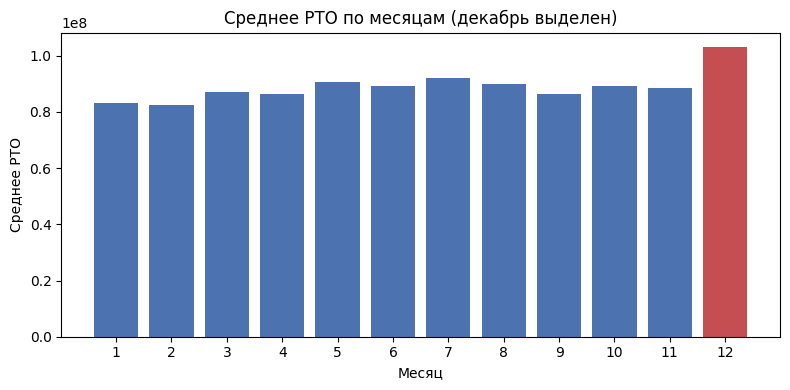

Декабрь выше среднего по остальным месяцам на 17.5%
Доля всех IQR-выбросов, приходящихся на декабрь: 40.6%


In [11]:
# Сезонность по месяцам + доля декабрьских выбросов
seas = df.groupby('Месяц')['РТО'].mean()
dec_share = (df[df['is_outlier']]['Месяц'] == 12).mean()

plt.figure(figsize=(8, 4))
colors = ['#C44E52' if m == 12 else '#4C72B0' for m in seas.index]
plt.bar(seas.index, seas.values, color=colors)
plt.title('Среднее РТО по месяцам (декабрь выделен)')
plt.xlabel('Месяц')
plt.ylabel('Среднее РТО')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig('images/seasonality_by_month.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Декабрь выше среднего по остальным месяцам на {seas[12] / seas.drop(12).mean() - 1:.1%}")
print(f"Доля всех IQR-выбросов, приходящихся на декабрь: {dec_share:.1%}")


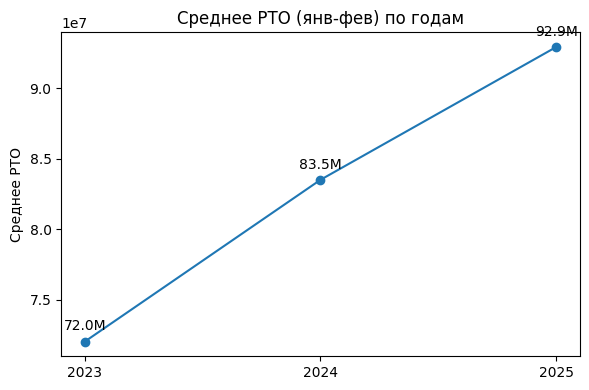

Рост 2024 к 2023 (янв-фев): 15.9%
Рост 2025 к 2024 (янв-фев): 11.3%


In [12]:
jf = df[df['Месяц'].isin([1, 2])].groupby('Год')['РТО'].mean()

plt.figure(figsize=(6, 4))
plt.plot(jf.index.astype(str), jf.values, marker='o')
for x, y in zip(jf.index.astype(str), jf.values):
    plt.annotate(f'{y/1e6:.1f}M', (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
plt.title('Среднее РТО (янв-фев) по годам')
plt.ylabel('Среднее РТО')
plt.tight_layout()
plt.savefig('images/yoy_growth_janfeb.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Рост 2024 к 2023 (янв-фев): {jf[2024]/jf[2023]-1:.1%}")
print(f"Рост 2025 к 2024 (янв-фев): {jf[2025]/jf[2024]-1:.1%}")


In [13]:
df = df.drop(columns=["is_outlier"])

df["is_december"] = (df["Месяц"] == 12).astype(int)

print(f"Асимметрия РТО: {df['РТО'].skew():.3f}")
print(f"Асимметрия log(1 + РТО): {np.log1p(df['РТО']).skew():.3f}")

Асимметрия РТО: 1.986
Асимметрия log(1 + РТО): 0.374


In [14]:
lag_periods = [1, 2, 3, 6, 12]

for lag in lag_periods:
    df[f'РТО_lag_{lag}'] = df.groupby('new_id')['РТО'].shift(lag)

In [15]:
df['trend_momentum'] = ((df['РТО_lag_1'] / df['РТО_lag_2']) - 1).replace([np.inf, -np.inf], 0).fillna(0)
df['trend_yearly'] = ((df['РТО_lag_1'] / df['РТО_lag_12']) - 1).replace([np.inf, -np.inf], 0).fillna(0)

In [16]:
CLIP_LOW, CLIP_HIGH = -0.9, 3.0

df['trend_momentum_clipped'] = df['trend_momentum'].clip(CLIP_LOW, CLIP_HIGH)
df['trend_yearly_clipped'] = df['trend_yearly'].clip(CLIP_LOW, CLIP_HIGH)

print(f"Обрезано trend_momentum: {(df['trend_momentum'] != df['trend_momentum_clipped']).sum()}")
print(f"Обрезано trend_yearly: {(df['trend_yearly'] != df['trend_yearly_clipped']).sum()}")

Обрезано trend_momentum: 91
Обрезано trend_yearly: 136


In [17]:
df["РТО_roll_mean_3"] = (
    df.groupby("new_id")["РТО"]
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

for window in [3, 6, 12]:
    df[f"РТО_roll_std_{window}"] = (
        df.groupby("new_id")["РТО"]
        .transform(lambda x: x.shift(1).rolling(window, min_periods=2).std())
    )

In [18]:
# Календарные признаки
df['month_sin'] = np.sin(2 * np.pi * df['Месяц'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Месяц'] / 12)
df['is_december'] = (df['Месяц'] == 12).astype(int)

# Квартал
df['quarter'] = df['date'].dt.quarter
df['quarter_sin'] = np.sin(2 * np.pi * df['quarter'] / 4)
df['quarter_cos'] = np.cos(2 * np.pi * df['quarter'] / 4)
df['is_q4'] = (df['quarter'] == 4).astype(int)

# Год как нормализованный тренд
df['year_norm'] = (df['Год'] - df['Год'].min()) / (df['Год'].max() - df['Год'].min())

In [19]:
df['доля_пятерочек'] = df['Пятерочки (500 м)'] / (df['Продуктовые магазины (500 м)'] + 1)
df['инфра_индекс'] = (
    df['Медицинские уч. и аптеки (300 м)'] +
    df['Школы (300 м)'] +
    df['Остановки (300 м)']
)

In [20]:
opening_order = {
    'Новый': 0,
    'Средний по возрасту': 1,
    'Открыт давно': 2
}
df['Дата открытия, enc'] = df['Дата открытия, категориальный'].map(opening_order)

area_order = {
    'Маленький': 0,
    'Средний': 1,
    'Большой': 2,
    'Очень большой': 3
}
df['Торговая площадь, enc'] = df['Торговая площадь, категориальный'].map(area_order)

print(f"NaN Дата открытия: {df['Дата открытия, enc'].isnull().sum()}")
print(f"NaN Торговая площадь: {df['Торговая площадь, enc'].isnull().sum()}")

NaN Дата открытия: 0
NaN Торговая площадь: 0


In [21]:
le_region = LabelEncoder()
le_city = LabelEncoder()

df["Регион_enc"] = le_region.fit_transform(df["Регион"].astype(str))
df["Город_enc"] = le_city.fit_transform(df["Населенный пункт"].astype(str))

print(f"NaN: {df[['Регион_enc', 'Город_enc']].isna().sum().sum()}")

NaN: 0


In [22]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

exclude = ["new_id", "Год", "Месяц", "quarter"]

corr_cols = [col for col in numeric_cols if col not in exclude]

corr_with_target = (
    df[corr_cols]
    .corrwith(df["РТО"], method="spearman")
    .sort_values(ascending=False)
)

print(corr_with_target)

РТО                                          1.000000
РТО_lag_1                                    0.967618
РТО_roll_mean_3                              0.962161
РТО_lag_12                                   0.950580
РТО_lag_2                                    0.948441
РТО_lag_3                                    0.931878
РТО_lag_6                                    0.897837
РТО_roll_std_12                              0.675414
Среднее количество отмен                     0.638716
РТО_roll_std_6                               0.624184
Количество касс                              0.562109
РТО_roll_std_3                               0.511354
Торговая площадь, enc                        0.449889
Среднее количество товаров в чеке            0.409167
Среднее количество промо товаров в чеке      0.202379
инфра_индекс                                 0.190131
Остановки (300 м)                            0.188785
Маркетплейсы, доставки, постаматы (100 м)    0.179378
Количество домохозяйств     

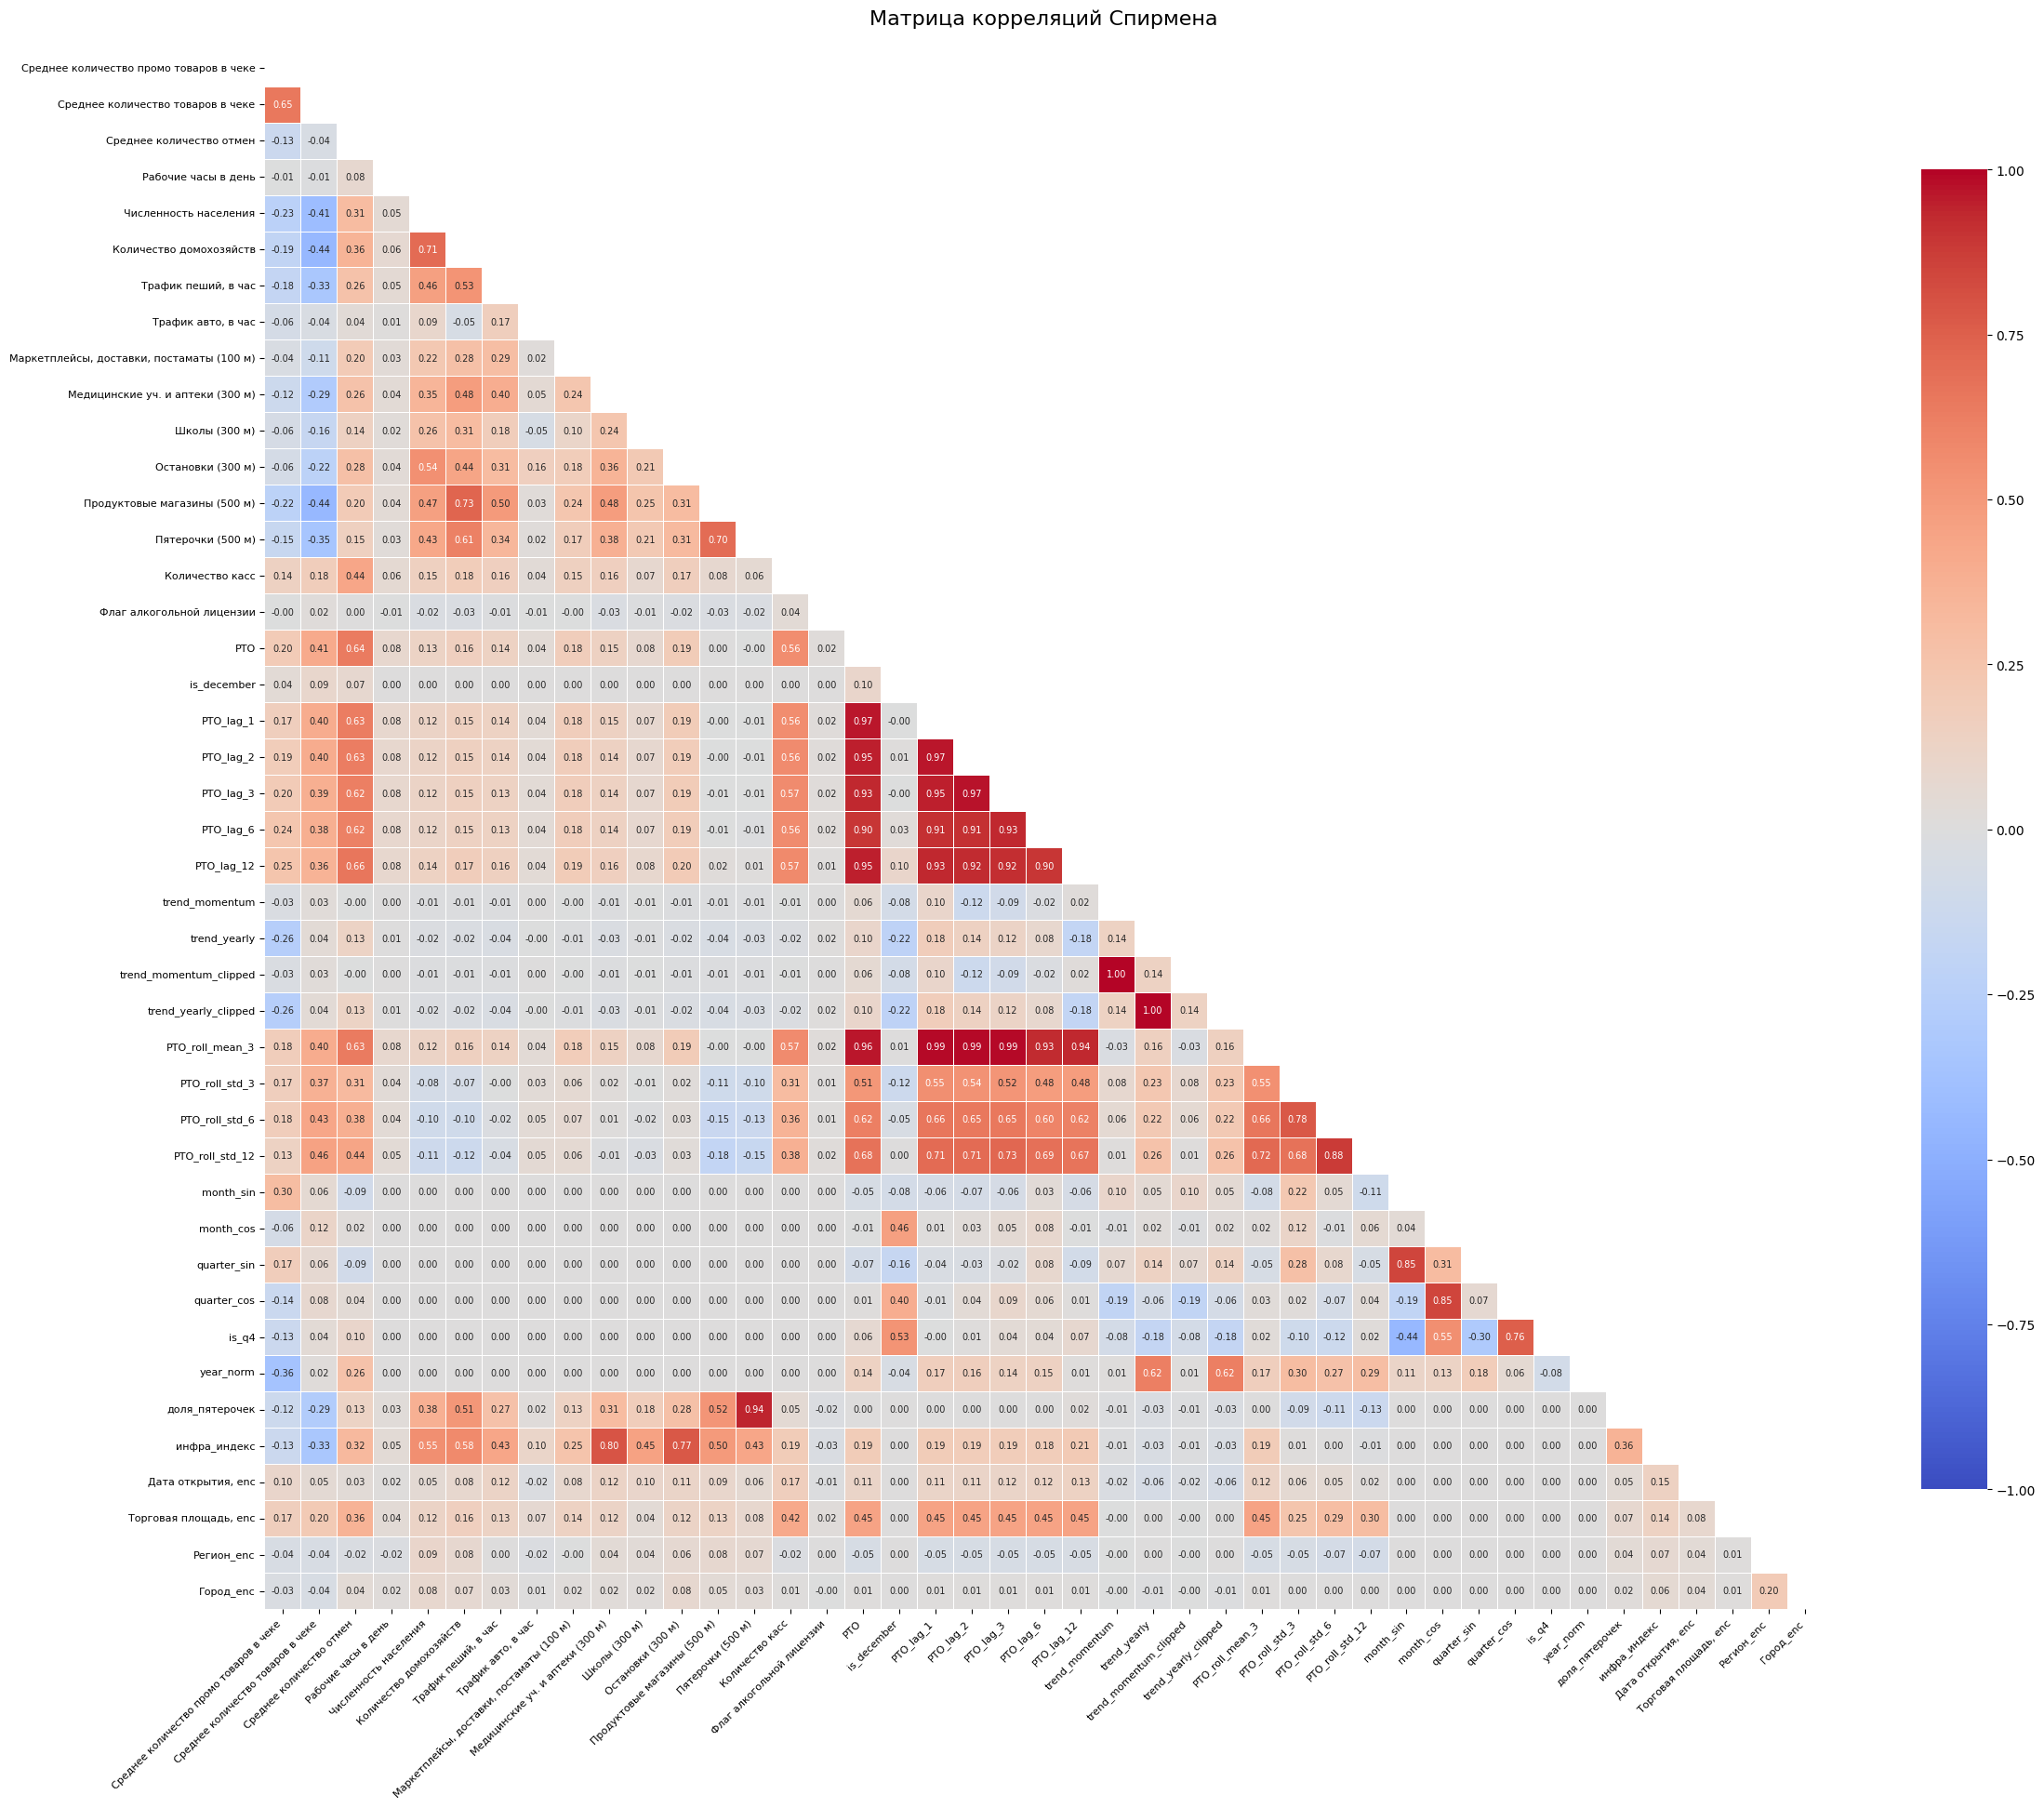

In [23]:
# матрица корреляций
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude = ['new_id', 'Год', 'Месяц', 'quarter']
corr_cols = [c for c in numeric_cols if c not in exclude]
corr_matrix = df[corr_cols].corr(method='spearman')

plt.figure(figsize=(24, 20))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 7},
    cbar_kws={'shrink': 0.8}
)
plt.title('Матрица корреляций Спирмена', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('images/full_correlation_matrix.png', dpi=110, bbox_inches='tight')
plt.show()

In [24]:
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr = corr_matrix.iloc[i, j]

        if abs(corr) > 0.85:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]

            high_corr_pairs.append({
                "Признак 1": col1,
                "Признак 2": col2,
                "Корреляция": round(corr, 3),
                "Корр. с РТО (1)": round(corr_matrix.loc[col1, "РТО"], 3),
                "Корр. с РТО (2)": round(corr_matrix.loc[col2, "РТО"], 3),
            })

high_corr_df = (
    pd.DataFrame(high_corr_pairs)
    .sort_values("Корреляция", ascending=False)
)

print(f"Пар с корреляцией > 0.85: {len(high_corr_df)}")
print(high_corr_df)

Пар с корреляцией > 0.85: 25
            Признак 1               Признак 2  Корреляция  Корр. с РТО (1)  \
23       trend_yearly    trend_yearly_clipped       1.000            0.096   
22     trend_momentum  trend_momentum_clipped       1.000            0.056   
15          РТО_lag_2         РТО_roll_mean_3       0.991            0.948   
18          РТО_lag_3         РТО_roll_mean_3       0.986            0.932   
11          РТО_lag_1         РТО_roll_mean_3       0.986            0.968   
12          РТО_lag_2               РТО_lag_3       0.969            0.948   
1                 РТО               РТО_lag_1       0.968            1.000   
7           РТО_lag_1               РТО_lag_2       0.967            0.968   
6                 РТО         РТО_roll_mean_3       0.962            1.000   
8           РТО_lag_1               РТО_lag_3       0.952            0.968   
5                 РТО              РТО_lag_12       0.951            1.000   
2                 РТО              

In [25]:
service_cols = [
    'Дата открытия, категориальный',
    'Торговая площадь, категориальный',
    'Населенный пункт',      
    'Регион',                           
    'Пятерочки (500 м)',
]

df = df.drop(columns=service_cols)

print(f"Колонок осталось: {len(df.columns)}")
print(f"Строк: {len(df)}")
print(f"Пропусков: {df.isnull().sum().sum()}")

Колонок осталось: 47
Строк: 485082
Пропусков: 578367


In [26]:
sorted_dates = sorted(df['date'].unique())
train = df[df['date'].isin(sorted_dates[:-3])].copy()
test  = df[df['date'].isin(sorted_dates[-3:])].copy()

In [27]:
for col, name in [('Регион_enc', 'Регион_target_enc'), ('Город_enc', 'Город_target_enc')]:
    enc = train.groupby(col)['РТО'].mean().rename(name)
    train[name] = train[col].map(enc)
    test[name]  = test[col].map(enc)

print(f"NaN target enc в test: {test[['Регион_target_enc', 'Город_target_enc']].isnull().sum().sum()}")

NaN target enc в test: 0


In [28]:
train = train.drop(columns=['date'])
test  = test.drop(columns=['date'])

train = train.dropna(subset=['РТО_lag_12']).reset_index(drop=True)

In [29]:
feature_cols = [c for c in train.columns if c not in ['new_id', 'РТО'   , 'Регион_enc', 'Город_enc']]

print(f"Пропусков в train: {train[feature_cols].isna().sum().sum()}")
print(f"Пропусков в test: {test[feature_cols].isna().sum().sum()}")

Пропусков в train: 0
Пропусков в test: 0


In [30]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_percentage_error

y_train = np.log1p(train['РТО'])
y_test = np.log1p(test['РТО'])

X_train = train[feature_cols]
X_test = test[feature_cols]


In [31]:
cb_single = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.01,
    depth=8,
    l2_leaf_reg=5,
    loss_function='RMSE',
    eval_metric='MAPE',
    random_seed=2026,
    early_stopping_rounds=150,
    verbose=300
)

cb_single.fit(X_train, y_train, eval_set=(X_test, y_test), use_best_model=True)

single_preds = np.expm1(cb_single.predict(X_test))
mape_single = mean_absolute_percentage_error(np.expm1(y_test), single_preds) * 100
print(f"MAPE (holdout): {mape_single:.2f}%")


0:	learn: 0.0200420	test: 0.0199772	best: 0.0199772 (0)	total: 73.5ms	remaining: 3m 40s
300:	learn: 0.0031143	test: 0.0045303	best: 0.0045303 (300)	total: 3.83s	remaining: 34.3s
600:	learn: 0.0023949	test: 0.0043391	best: 0.0042822 (463)	total: 7.4s	remaining: 29.5s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.004282237868
bestIteration = 463

Shrink model to first 464 iterations.
MAPE (holdout): 7.74%


In [32]:
volatility = (test['РТО_roll_std_3'] / (test['РТО_roll_mean_3'] + 1)).clip(0.05, 1.0)
band = 1 + volatility * 2

lower_bound = test['РТО_lag_1'].values / band.values
upper_bound = test['РТО_lag_1'].values * band.values
single_preds_clipped = np.clip(single_preds, lower_bound, upper_bound)

mape_clipped = mean_absolute_percentage_error(np.expm1(y_test), single_preds_clipped) * 100

print(f"MAPE (holdout, с адаптивным клипом): {mape_clipped:.2f}%")
print(f"Прогнозов под клипом: {((single_preds < lower_bound) | (single_preds > upper_bound)).sum()} из {len(single_preds)}")

MAPE (holdout, с адаптивным клипом): 7.67%
Прогнозов под клипом: 6776 из 55971


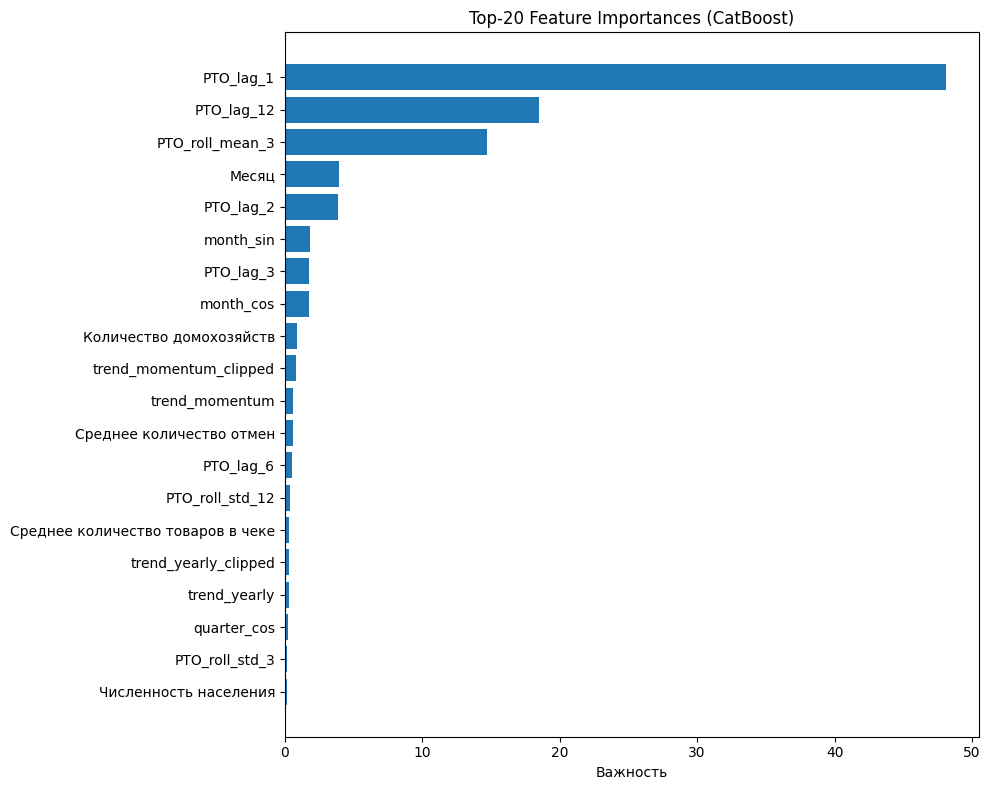

,Признак,Важность
18,РТО_lag_1,48.076028
22,РТО_lag_12,18.519396
27,РТО_roll_mean_3,14.742196
1,Месяц,3.905804
19,РТО_lag_2,3.855333
31,month_sin,1.861689
20,РТО_lag_3,1.744984
32,month_cos,1.725951
7,Количество домохозяйств,0.891923
25,trend_momentum_clipped,0.780823


In [ ]:
feature_importance = (
    pd.DataFrame({
        "Признак": X_train.columns,
        "Важность": cb_single.get_feature_importance()
    })
    .sort_values("Важность", ascending=False)
)

plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance["Признак"][:20][::-1],
    feature_importance["Важность"][:20][::-1]
)
plt.xlabel("Важность")
plt.title("Top-20 Feature Importances")
plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=130, bbox_inches="tight")
plt.show()

display(feature_importance.head(20))

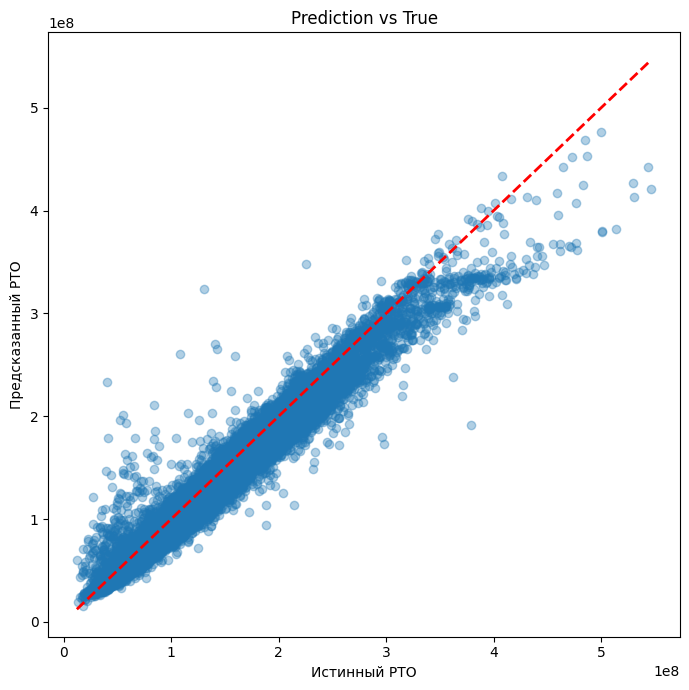

In [34]:
plt.figure(figsize=(7, 7))

plt.scatter(
    np.expm1(y_test),
    single_preds_clipped,
    alpha=0.35
)

lims = [
    min(np.expm1(y_test).min(), single_preds_clipped.min()),
    max(np.expm1(y_test).max(), single_preds_clipped.max())
]

plt.plot(lims, lims, "r--", linewidth=2)

plt.xlabel("Истинный РТО")
plt.ylabel("Предсказанный РТО")
plt.title("Prediction vs True")
plt.tight_layout()

plt.savefig(
    "images/prediction_vs_true.png",
    dpi=130,
    bbox_inches="tight"
)

plt.show()

In [35]:
errors = pd.DataFrame({
    "new_id": test["new_id"],
    "True": np.expm1(y_test),
    "Prediction": single_preds_clipped
})

errors["APE"] = (
    np.abs(errors["Prediction"] - errors["True"])
    / errors["True"]
    * 100
)

display(
    errors.sort_values("APE", ascending=False).head(20)
)
print(errors["APE"].describe())

,new_id,True,Prediction,APE
97446,4388,40071340.00,2.333075e+08,482.230277
283633,12740,12364028.71,6.032553e+07,387.911616
477099,21385,26954203.92,1.210540e+08,349.109908
41209,1860,41375249.08,1.788838e+08,332.344963
124563,5606,17702185.50,7.100934e+07,301.133193
304458,13652,52206877.48,1.964850e+08,276.358451
243489,10933,39200448.07,1.465489e+08,273.844985
244737,10991,54881654.76,2.015598e+08,267.262548
16508,747,22411139.97,8.077340e+07,260.416313
437605,19602,22651730.85,7.836950e+07,245.975759


count    55971.000000
mean         7.672898
std          9.468987
min          0.000107
25%          2.765620
50%          6.121045
75%         10.736368
max        482.230277
Name: APE, dtype: float64


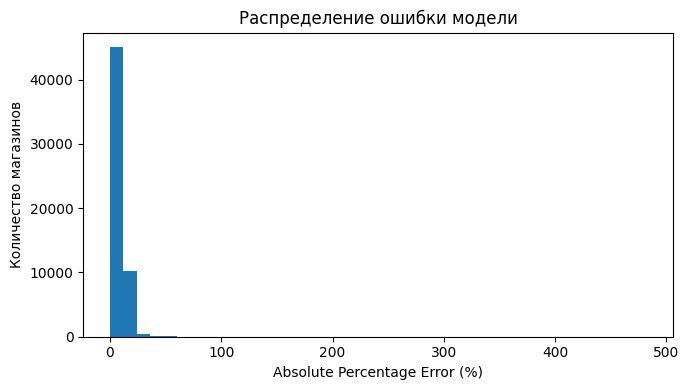

In [36]:
plt.figure(figsize=(7, 4))

plt.hist(errors["APE"], bins=40)

plt.xlabel("Absolute Percentage Error (%)")
plt.ylabel("Количество магазинов")
plt.title("Распределение ошибки модели")

plt.tight_layout()

plt.savefig(
    "images/error_distribution.png",
    dpi=130,
    bbox_inches="tight"
)

plt.show()

## Прогноз на март 2025 и сохранение сабмита

In [37]:
march_df_base = (
    df.groupby("new_id", group_keys=False)
      .tail(1)
      .copy()
)

march_df_base["Год"] = 2025
march_df_base["Месяц"] = 3
march_df_base["date"] = pd.Timestamp("2025-03-01")
march_df_base["РТО"] = np.nan
df_combined = pd.concat([df, march_df_base], ignore_index=True).sort_values(['new_id', 'date']).reset_index(drop=True)

for lag in [1, 2, 3, 6, 12]:
    df_combined[f'РТО_lag_{lag}'] = df_combined.groupby('new_id')['РТО'].shift(lag)

CLIP_LOW, CLIP_HIGH = -0.9, 3.0

df_combined['РТО_roll_mean_3'] = df_combined.groupby('new_id')['РТО'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
df_combined['РТО_roll_std_3'] = df_combined.groupby('new_id')['РТО'].transform(lambda x: x.shift(1).rolling(3, min_periods=1).std())
df_combined['trend_momentum'] = ((df_combined['РТО_lag_1'] / df_combined['РТО_lag_2']) - 1).clip(CLIP_LOW, CLIP_HIGH)
df_combined['trend_yearly'] = ((df_combined['РТО_lag_1'] / df_combined['РТО_lag_12']) - 1).clip(CLIP_LOW, CLIP_HIGH)
df_combined['trend_momentum'] = df_combined['trend_momentum'].replace([np.inf, -np.inf], 0).fillna(0)
df_combined['trend_yearly'] = df_combined['trend_yearly'].replace([np.inf, -np.inf], 0).fillna(0)
df_combined['year_norm'] = (df_combined['Год'] - df_combined['Год'].min()) / (df_combined['Год'].max() - df_combined['Год'].min())

march_df = df_combined[(df_combined['Год'] == 2025) & (df_combined['Месяц'] == 3)].copy()

region_enc = train.groupby('Регион_enc')['РТО'].mean()
city_enc = train.groupby('Город_enc')['РТО'].mean()
march_df['Регион_target_enc'] = march_df['Регион_enc'].map(region_enc)
march_df['Город_target_enc'] = march_df['Город_enc'].map(city_enc)

march_features = march_df[feature_cols]
march_preds = np.expm1(cb_single.predict(march_features))

volatility_march = (march_df['РТО_roll_std_3'] / (march_df['РТО_roll_mean_3'] + 1)).clip(0.05, 1.0)
band_march = 1 + volatility_march * 2

lower_bound_march = march_df["РТО_lag_1"] / band_march
upper_bound_march = march_df["РТО_lag_1"] * band_march
march_preds_clipped = np.clip(march_preds, lower_bound_march, upper_bound_march)

submission = pd.DataFrame({
    'new_id': march_df_base['new_id'].values,
    'rto': march_preds_clipped
})
assert len(submission) == df['new_id'].nunique(), "строк должно быть ровно по числу магазинов"
assert submission['rto'].isna().sum() == 0, "не должно быть NaN"

submission.to_csv('submission.csv', index=False)
print("Файл 'submission.csv' создан.")


Файл 'submission.csv' создан.
